<a href="https://colab.research.google.com/github/ananyabatra04/fairness-graph-gnn/blob/main/4_GCN_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# Cell 1: path + setup + data + helpers
# =========================================================

!pip -q install torch-geometric pandas numpy scikit-learn

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from collections import Counter
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


# -------------------------
# basic config
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = list(range(10))
print("Device:", device)
print("Seeds :", SEEDS)

BASE_DIR = "/content/drive/MyDrive/courses/network/project/dataset"

DATASETS = {
    "nba": {
        "csv": os.path.join(BASE_DIR, "nba", "nba.csv"),
        "edge": os.path.join(BASE_DIR, "nba", "nba_relationship.txt"),
    },
    "pokec_z": {
        "csv": os.path.join(BASE_DIR, "pokec", "region_job.csv"),
        "edge": os.path.join(BASE_DIR, "pokec", "region_job_relationship.txt"),
    }
}

TASK_CONFIG = {
    "nba": {
        "id_col": "user_id",
        "label_col": "SALARY",
        "sens_col": "country",
    },
    "pokec_z": {
        "id_col": "user_id",
        "label_col": "I_am_working_in_field",
        "sens_col": "region",
    }
}

RUN_CONFIG = {
    "nba": {
        "hidden_dim": 64,
        "repr_dim": 64,
        "proj_dim": 64,
        "dropout": 0.6,            # encoder dropout
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 300,
        "patience": 50,

        # contrastive
        "pretrain_epochs": 200,
        "pretrain_lr": 1e-3,
        "edge_drop_prob": 0.2,     # p_edge
        "feat_mask_prob": 0.2,     # p_feat
        "temperature": 0.5,        # tau
        "lambda_cl_fair": 1.0,
        "contrast_batch_size": 512,

        # fairdrop
        "fair_keep_same": 0.5,     # drop 50% edge from same group
        "fair_keep_diff": 1.0,     # no drop on edge between groups
    },
    "pokec_z": {
        "hidden_dim": 64,
        "repr_dim": 64,
        "proj_dim": 64,
        "dropout": 0.6,
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 300,
        "patience": 50,

        # contrastive
        "pretrain_epochs": 200,
        "pretrain_lr": 1e-3,
        "edge_drop_prob": 0.2,
        "feat_mask_prob": 0.2,
        "temperature": 0.5,
        "lambda_cl_fair": 1.0,
        "contrast_batch_size": 2048,

        # fairdrop
        "fair_keep_same": 0.5,
        "fair_keep_diff": 1.0,
    }
}

SAVE_DIR = os.path.join(BASE_DIR, "results_gcn_4models")
os.makedirs(SAVE_DIR, exist_ok=True)

for ds_name, paths in DATASETS.items():
    print(f"\n[{ds_name}]")
    for k, v in paths.items():
        print(f"  {k}: {v} | exists={os.path.exists(v)}")


# -------------------------
# utilities
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_raw_edges(edge_path):
    edges = []
    with open(edge_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if "," in line:
                parts = line.split(",")
            elif "\t" in line:
                parts = line.split("\t")
            else:
                parts = line.split()

            if len(parts) < 2:
                continue

            try:
                u = int(parts[0])
                v = int(parts[1])
                edges.append((u, v))
            except:
                continue
    return edges


def build_graph_from_raw_csv(csv_path, edge_path, id_col, label_col, sens_col, name="dataset"):

    df = pd.read_csv(csv_path).copy()
    raw_edges = read_raw_edges(edge_path)

    if id_col not in df.columns or label_col not in df.columns or sens_col not in df.columns:
        raise ValueError(f"{name}: check id/label/sens column names")

    df = df.drop_duplicates(subset=[id_col]).copy()

    df = df[df[label_col].isin([0, 1]) & df[sens_col].isin([0, 1])].copy()

    edge_nodes = set()
    for u, v in raw_edges:
        edge_nodes.add(u)
        edge_nodes.add(v)

    common_nodes = sorted(set(df[id_col]) & edge_nodes)
    df = df[df[id_col].isin(common_nodes)].copy()
    df = df.set_index(id_col).loc[common_nodes]

    feature_df = df.drop(columns=[label_col, sens_col]).copy()

    # object/categorical -> one-hot
    cat_cols = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    if len(cat_cols) > 0:
        feature_df = pd.get_dummies(feature_df, columns=cat_cols, dummy_na=True)

    feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    for c in feature_df.columns:
        feature_df[c] = pd.to_numeric(feature_df[c], errors="coerce")
    feature_df = feature_df.fillna(0).astype(np.float32)

    node_map = {nid: i for i, nid in enumerate(common_nodes)}

    remapped_edges = []
    for u, v in raw_edges:
        if u in node_map and v in node_map and u != v:
            remapped_edges.append((node_map[u], node_map[v]))

    # undirected + deduplicate
    remapped_edges = remapped_edges + [(v, u) for u, v in remapped_edges]
    remapped_edges = sorted(set(remapped_edges))

    edge_index = torch.tensor(remapped_edges, dtype=torch.long).t().contiguous()
    x = torch.tensor(feature_df.values, dtype=torch.float32)
    y = torch.tensor(df[label_col].values, dtype=torch.long)
    s = torch.tensor(df[sens_col].values, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.s = s
    data.node_ids = torch.tensor(common_nodes, dtype=torch.long)

    print(f"\n===== {name} =====")
    print("num_nodes:", data.num_nodes)
    print("num_edges:", data.edge_index.shape[1])
    print("x shape  :", tuple(data.x.shape))
    print("y dist   :", Counter(data.y.tolist()))
    print("s dist   :", Counter(data.s.tolist()))

    return data


def create_masks_70_15_15(y, seed):
    """
    stratified split:
    train = 70%
    val   = 15%
    test  = 15%
    """
    idx = np.arange(len(y))

    train_idx, temp_idx = train_test_split(
        idx,
        train_size=0.70,
        random_state=seed,
        stratify=y
    )

    temp_y = y[temp_idx]
    val_rel, test_rel = train_test_split(
        np.arange(len(temp_idx)),
        train_size=0.50,
        random_state=seed,
        stratify=temp_y
    )

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    train_mask = torch.zeros(len(y), dtype=torch.bool)
    val_mask = torch.zeros(len(y), dtype=torch.bool)
    test_mask = torch.zeros(len(y), dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask


# -------------------------
# fairness metrics
# -------------------------
def statistical_parity(pred, sens):
    """
    | P(\hat{Y}=1 | S=0) - P(\hat{Y}=1 | S=1) |
    """
    pred = np.asarray(pred)
    sens = np.asarray(sens)

    mask0 = sens == 0
    mask1 = sens == 1

    if mask0.sum() == 0 or mask1.sum() == 0:
        return np.nan

    p0 = pred[mask0].mean()
    p1 = pred[mask1].mean()
    return abs(p0 - p1)


def equal_opportunity(pred, y_true, sens):
    """
    | TPR(S=0) - TPR(S=1) |
    """
    pred = np.asarray(pred)
    y_true = np.asarray(y_true)
    sens = np.asarray(sens)

    mask0 = (sens == 0) & (y_true == 1)
    mask1 = (sens == 1) & (y_true == 1)

    if mask0.sum() == 0 or mask1.sum() == 0:
        return np.nan

    tpr0 = pred[mask0].mean()
    tpr1 = pred[mask1].mean()
    return abs(tpr0 - tpr1)


# -------------------------
# edge augmentation
# -------------------------
def get_undirected_pairs(edge_index):
    row, col = edge_index
    mask = row < col
    pairs = edge_index[:, mask]
    if pairs.numel() == 0:
        return edge_index
    return pairs


def make_bidirectional(pairs):
    rev = pairs[[1, 0], :]
    return torch.cat([pairs, rev], dim=1).contiguous()


def random_edge_drop(edge_index, keep_prob=0.8):
    pairs = get_undirected_pairs(edge_index)
    if pairs.numel() == 0:
        return edge_index

    mask = torch.rand(pairs.size(1), device=edge_index.device) < keep_prob
    if mask.sum() == 0:
        mask[torch.randint(0, pairs.size(1), (1,), device=edge_index.device)] = True

    return make_bidirectional(pairs[:, mask])


def fairdrop_edge_drop(edge_index, sens, keep_prob_same=0.5, keep_prob_diff=1.0):

    pairs = get_undirected_pairs(edge_index)
    if pairs.numel() == 0:
        return edge_index

    row, col = pairs
    same_group = (sens[row] == sens[col])

    probs = torch.where(
        same_group,
        torch.full((pairs.size(1),), keep_prob_same, device=edge_index.device),
        torch.full((pairs.size(1),), keep_prob_diff, device=edge_index.device),
    )

    mask = torch.rand(pairs.size(1), device=edge_index.device) < probs
    if mask.sum() == 0:
        mask[torch.randint(0, pairs.size(1), (1,), device=edge_index.device)] = True

    return make_bidirectional(pairs[:, mask])


def feature_mask(x, mask_prob=0.2):
    keep = (torch.rand_like(x) > mask_prob).float()
    return x * keep


# -------------------------
# models
# -------------------------
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, repr_dim=64, dropout=0.6):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, repr_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class GCNClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, repr_dim=64, num_classes=2, dropout=0.6):
        super().__init__()
        self.encoder = GCNEncoder(in_dim, hidden_dim, repr_dim, dropout)
        self.classifier = nn.Linear(repr_dim, num_classes)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        logits = self.classifier(F.relu(z))
        return logits, z


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# contrastive pretrain
# -------------------------
def sampled_nt_xent(z1, z2, temperature=0.5, batch_size=2048):
    n = z1.size(0)
    bs = min(batch_size, n)

    idx = torch.randperm(n, device=z1.device)[:bs]

    a = F.normalize(z1[idx], dim=1)
    b = F.normalize(z2[idx], dim=1)

    logits_ab = torch.mm(a, b.t()) / temperature
    logits_ba = torch.mm(b, a.t()) / temperature
    labels = torch.arange(bs, device=z1.device)

    loss_ab = F.cross_entropy(logits_ab, labels)
    loss_ba = F.cross_entropy(logits_ba, labels)
    return 0.5 * (loss_ab + loss_ba)


def fair_contrastive_penalty(z, sens):

    z = F.normalize(z, dim=1)

    z0 = z[sens == 0]
    z1 = z[sens == 1]

    if z0.size(0) == 0 or z1.size(0) == 0:
        return z.new_tensor(0.0)

    return ((z0.mean(dim=0) - z1.mean(dim=0)) ** 2).mean()


def pretrain_encoder(data, cfg, seed, use_fairdrop=False):
    set_seed(seed)

    data = data.to(device)

    encoder = GCNEncoder(
        in_dim=data.x.size(1),
        hidden_dim=cfg["hidden_dim"],
        repr_dim=cfg["repr_dim"],
        dropout=cfg["dropout"]
    ).to(device)

    projector = ProjectionHead(
        in_dim=cfg["repr_dim"],
        proj_dim=cfg["proj_dim"]
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(projector.parameters()),
        lr=cfg["pretrain_lr"],
        weight_decay=1e-5
    )

    for epoch in range(cfg["pretrain_epochs"]):
        encoder.train()
        projector.train()
        optimizer.zero_grad()

        if use_fairdrop:
            edge1 = fairdrop_edge_drop(
                data.edge_index, data.s,
                keep_prob_same=cfg["fair_keep_same"],
                keep_prob_diff=cfg["fair_keep_diff"]
            )
            edge2 = fairdrop_edge_drop(
                data.edge_index, data.s,
                keep_prob_same=cfg["fair_keep_same"],
                keep_prob_diff=cfg["fair_keep_diff"]
            )
        else:
            edge1 = random_edge_drop(data.edge_index, keep_prob=1 - cfg["edge_drop_prob"])
            edge2 = random_edge_drop(data.edge_index, keep_prob=1 - cfg["edge_drop_prob"])

        x1 = feature_mask(data.x, mask_prob=cfg["feat_mask_prob"])
        x2 = feature_mask(data.x, mask_prob=cfg["feat_mask_prob"])

        h1 = encoder(x1, edge1)
        h2 = encoder(x2, edge2)

        z1 = projector(h1)
        z2 = projector(h2)

        loss_cl = sampled_nt_xent(
            z1, z2,
            temperature=cfg["temperature"],
            batch_size=cfg["contrast_batch_size"]
        )

        z_avg = 0.5 * (z1 + z2)
        loss_fair = fair_contrastive_penalty(z_avg, data.s)

        loss = loss_cl + cfg["lambda_cl_fair"] * loss_fair
        loss.backward()
        optimizer.step()

    encoder_state = {k: v.detach().cpu().clone() for k, v in encoder.state_dict().items()}
    return encoder_state


# -------------------------
# supervised train/eval
# -------------------------
def train_and_evaluate(data, cfg, seed, use_fairdrop=False, pretrained_encoder_state=None):
    set_seed(seed)

    y_np = data.y.cpu().numpy()
    train_mask, val_mask, test_mask = create_masks_70_15_15(y_np, seed)

    data = data.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    model = GCNClassifier(
        in_dim=data.x.size(1),
        hidden_dim=cfg["hidden_dim"],
        repr_dim=cfg["repr_dim"],
        num_classes=2,
        dropout=cfg["dropout"]
    ).to(device)

    if pretrained_encoder_state is not None:
        model.encoder.load_state_dict(pretrained_encoder_state)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    best_val_acc = -1
    best_state = None
    wait = 0

    for epoch in range(cfg["epochs"]):
        model.train()
        optimizer.zero_grad()

        if use_fairdrop:
            train_edge_index = fairdrop_edge_drop(
                data.edge_index, data.s,
                keep_prob_same=cfg["fair_keep_same"],
                keep_prob_diff=cfg["fair_keep_diff"]
            )
        else:
            train_edge_index = data.edge_index

        logits, _ = model(data.x, train_edge_index)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index)
            val_pred = val_logits[val_mask].argmax(dim=1)
            val_acc = (val_pred == data.y[val_mask]).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break

    model.load_state_dict(best_state)
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        test_logits, _ = model(data.x, data.edge_index)
        test_pred = test_logits[test_mask].argmax(dim=1).cpu().numpy()
        y_true = data.y[test_mask].cpu().numpy()
        sens = data.s[test_mask].cpu().numpy()

    result = {
        "seed": seed,
        "accuracy": accuracy_score(y_true, test_pred),
        "statistical_parity": statistical_parity(test_pred, sens),
        "equal_opportunity": equal_opportunity(test_pred, y_true, sens),
    }
    return result


def run_experiment(mode_name, data_dict):
    """
    mode_name in:
    - baseline
    - fairdrop
    - contrastive
    - fairdrop_contrastive
    """
    all_results = {}

    for ds_name, data in data_dict.items():
        cfg = RUN_CONFIG[ds_name]
        rows = []

        print(f"\n==============================")
        print(f"Running {mode_name} on {ds_name}")
        print(f"==============================")

        for seed in SEEDS:
            pretrained = None

            if mode_name == "contrastive":
                pretrained = pretrain_encoder(
                    data=data,
                    cfg=cfg,
                    seed=seed,
                    use_fairdrop=False
                )

            elif mode_name == "fairdrop_contrastive":
                pretrained = pretrain_encoder(
                    data=data,
                    cfg=cfg,
                    seed=seed,
                    use_fairdrop=True
                )

            use_fairdrop = mode_name in ["fairdrop", "fairdrop_contrastive"]

            result = train_and_evaluate(
                data=data,
                cfg=cfg,
                seed=seed,
                use_fairdrop=use_fairdrop,
                pretrained_encoder_state=pretrained
            )

            rows.append(result)
            print(
                f"seed={seed} | "
                f"acc={result['accuracy']:.4f} | "
                f"sp={result['statistical_parity']:.4f} | "
                f"eo={result['equal_opportunity']:.4f}"
            )

        df = pd.DataFrame(rows)
        all_results[ds_name] = df

    return all_results


def summarize_results(title, result_dict, save_prefix=None):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    summary_rows = []

    for ds_name, df in result_dict.items():
        print(f"\n--- {ds_name} per-seed results ---")
        display(df)

        means = df[["accuracy", "statistical_parity", "equal_opportunity"]].mean()
        stds = df[["accuracy", "statistical_parity", "equal_opportunity"]].std()

        print(f"\n{ds_name} mean:")
        print(means)
        print(f"\n{ds_name} std:")
        print(stds)

        summary_rows.append({
            "dataset": ds_name,
            "acc_mean": means["accuracy"],
            "acc_std": stds["accuracy"],
            "sp_mean": means["statistical_parity"],
            "sp_std": stds["statistical_parity"],
            "eo_mean": means["equal_opportunity"],
            "eo_std": stds["equal_opportunity"],
        })

        if save_prefix is not None:
            df.to_csv(os.path.join(SAVE_DIR, f"{save_prefix}_{ds_name}_per_seed.csv"), index=False)

    summary_df = pd.DataFrame(summary_rows)
    print(f"\n--- summary table ---")
    display(summary_df)

    if save_prefix is not None:
        summary_df.to_csv(os.path.join(SAVE_DIR, f"{save_prefix}_summary.csv"), index=False)

    return summary_df


# -------------------------
# build datasets now
# -------------------------
nba_data = build_graph_from_raw_csv(
    csv_path=DATASETS["nba"]["csv"],
    edge_path=DATASETS["nba"]["edge"],
    id_col=TASK_CONFIG["nba"]["id_col"],
    label_col=TASK_CONFIG["nba"]["label_col"],
    sens_col=TASK_CONFIG["nba"]["sens_col"],
    name="NBA"
)

pokec_data = build_graph_from_raw_csv(
    csv_path=DATASETS["pokec_z"]["csv"],
    edge_path=DATASETS["pokec_z"]["edge"],
    id_col=TASK_CONFIG["pokec_z"]["id_col"],
    label_col=TASK_CONFIG["pokec_z"]["label_col"],
    sens_col=TASK_CONFIG["pokec_z"]["sens_col"],
    name="Pokec-z"
)

DATA_OBJECTS = {
    "nba": nba_data,
    "pokec_z": pokec_data,
}

print("\nReady to run.")
print("Results will be saved to:", SAVE_DIR)

<>:293: SyntaxWarning: invalid escape sequence '\h'
<>:293: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_427/4267375093.py:293: SyntaxWarning: invalid escape sequence '\h'
  | P(\hat{Y}=1 | S=0) - P(\hat{Y}=1 | S=1) |


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00
Mounted at /content/drive
Device: cpu
Seeds : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[nba]
  csv: /content/drive/MyDrive/courses/network/project/dataset/nba/nba.csv | exists=True
  edge: /content/drive/MyDrive/courses/network/project/dataset/nba/nba_relationship.txt | exists=True

[pokec_z]
  csv: /content/drive/MyDrive/courses/network/project/dataset/pokec/region_job.csv | exists=True
  edge: /content/drive/MyDrive/courses/network/project/dataset/pokec/region_job_relationship.txt | exists=True

===== NBA =====
num_nodes: 310
num_edges: 14230
x shape  : (310, 95)
y dist   : Counter({1: 158, 0: 152})
s dist   : Counter({0: 228, 1: 82})

===== Pokec-z =====
num_nodes: 6728
num_edges: 19014
x shape  : (6728, 276)
y dist   : Counter({0: 4764, 1: 1964})
s dist   : Counter({0: 4332, 1: 2396})

Ready to run.
Results will be saved to: /content/dr

In [ ]:
# =========================================================
# Cell 2: (1) GCN baseline
# =========================================================

baseline_results = run_experiment("baseline", DATA_OBJECTS)
baseline_summary = summarize_results(
    title="(1) GCN baseline",
    result_dict=baseline_results,
    save_prefix="01_gcn_baseline"
)
baseline_summary


Running baseline on nba
seed=0 | acc=0.5745 | sp=0.0087 | eo=0.1250
seed=1 | acc=0.7021 | sp=0.1919 | eo=0.3895
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.8085 | sp=0.0760 | eo=0.2857
seed=4 | acc=0.6809 | sp=0.0429 | eo=0.1368
seed=5 | acc=0.5745 | sp=0.0906 | eo=0.1000
seed=6 | acc=0.6809 | sp=0.3514 | eo=0.5789
seed=7 | acc=0.6596 | sp=0.1255 | eo=0.3025
seed=8 | acc=0.6383 | sp=0.0303 | eo=0.0556
seed=9 | acc=0.5106 | sp=0.2179 | eo=0.1092

Running baseline on pokec_z
seed=0 | acc=0.8822 | sp=0.0195 | eo=0.0569
seed=1 | acc=0.8990 | sp=0.0795 | eo=0.0176
seed=2 | acc=0.8881 | sp=0.0067 | eo=0.1057
seed=3 | acc=0.8822 | sp=0.1041 | eo=0.0866
seed=4 | acc=0.8980 | sp=0.0698 | eo=0.0091
seed=5 | acc=0.8733 | sp=0.0594 | eo=0.0376
seed=6 | acc=0.8802 | sp=0.0265 | eo=0.0533
seed=7 | acc=0.8634 | sp=0.0253 | eo=0.0251
seed=8 | acc=0.8812 | sp=0.0501 | eo=0.0023
seed=9 | acc=0.8990 | sp=0.0282 | eo=0.0479

(1) GCN baseline

--- nba per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.574468,0.008658,0.125000
1,1,0.702128,0.191919,0.389474
2,2,0.489362,0.000000,0.000000
3,3,0.808511,0.076023,0.285714
4,4,0.680851,0.042857,0.136842
5,5,0.574468,0.090643,0.100000
6,6,0.680851,0.351351,0.578947
7,7,0.659574,0.125541,0.302521
8,8,0.638298,0.030303,0.055556
9,9,0.510638,0.217949,0.109244



nba mean:
accuracy              0.631915
statistical_parity    0.113525
equal_opportunity     0.208330
dtype: float64

nba std:
accuracy              0.096229
statistical_parity    0.111301
equal_opportunity     0.178070
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.882178,0.019527,0.056893
1,1,0.899010,0.079540,0.017631
2,2,0.888119,0.006688,0.105712
3,3,0.882178,0.104086,0.086610
4,4,0.898020,0.069830,0.009064
5,5,0.873267,0.059403,0.037639
6,6,0.880198,0.026505,0.053309
7,7,0.863366,0.025277,0.025092
8,8,0.881188,0.050104,0.002340
9,9,0.899010,0.028212,0.047901



pokec_z mean:
accuracy              0.884653
statistical_parity    0.046917
equal_opportunity     0.044219
dtype: float64

pokec_z std:
accuracy              0.011689
statistical_parity    0.030961
equal_opportunity     0.033235
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.631915,0.096229,0.113525,0.111301,0.208330,0.178070
1,pokec_z,0.884653,0.011689,0.046917,0.030961,0.044219,0.033235


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.631915,0.096229,0.113525,0.111301,0.208330,0.178070
1,pokec_z,0.884653,0.011689,0.046917,0.030961,0.044219,0.033235


In [ ]:
# =========================================================
# Cell 3: (2) FairDrop + GCN
# =========================================================

fairdrop_results = run_experiment("fairdrop", DATA_OBJECTS)
fairdrop_summary = summarize_results(
    title="(2) FairDrop + GCN",
    result_dict=fairdrop_results,
    save_prefix="02_fairdrop_gcn"
)
fairdrop_summary


Running fairdrop on nba
seed=0 | acc=0.5319 | sp=0.1342 | eo=0.1250
seed=1 | acc=0.5957 | sp=0.1970 | eo=0.3474
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.5319 | sp=0.1316 | eo=0.0952
seed=4 | acc=0.6170 | sp=0.0214 | eo=0.0947
seed=5 | acc=0.6170 | sp=0.1491 | eo=0.5000
seed=6 | acc=0.8085 | sp=0.0595 | eo=0.1895
seed=7 | acc=0.6596 | sp=0.0043 | eo=0.1849
seed=8 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5319 | sp=0.2564 | eo=0.1681

Running fairdrop on pokec_z
seed=0 | acc=0.8881 | sp=0.0390 | eo=0.0621
seed=1 | acc=0.8911 | sp=0.0561 | eo=0.0265
seed=2 | acc=0.8851 | sp=0.0252 | eo=0.1523
seed=3 | acc=0.8941 | sp=0.0892 | eo=0.0803
seed=4 | acc=0.8980 | sp=0.0586 | eo=0.0132
seed=5 | acc=0.8703 | sp=0.0576 | eo=0.0428
seed=6 | acc=0.8832 | sp=0.0151 | eo=0.0703
seed=7 | acc=0.8644 | sp=0.0291 | eo=0.0032
seed=8 | acc=0.8713 | sp=0.0301 | eo=0.0271
seed=9 | acc=0.9050 | sp=0.0596 | eo=0.0316

(2) FairDrop + GCN

--- nba per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.531915,0.134199,0.125000
1,1,0.595745,0.196970,0.347368
2,2,0.489362,0.000000,0.000000
3,3,0.531915,0.131579,0.095238
4,4,0.617021,0.021429,0.094737
5,5,0.617021,0.149123,0.500000
6,6,0.808511,0.059459,0.189474
7,7,0.659574,0.004329,0.184874
8,8,0.489362,0.000000,0.000000
9,9,0.531915,0.256410,0.168067



nba mean:
accuracy              0.587234
statistical_parity    0.095350
equal_opportunity     0.170476
dtype: float64

nba std:
accuracy              0.096829
statistical_parity    0.091409
equal_opportunity     0.153493
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.888119,0.038986,0.062075
1,1,0.891089,0.056058,0.026517
2,2,0.885149,0.025168,0.152331
3,3,0.894059,0.089179,0.080309
4,4,0.898020,0.058550,0.013243
5,5,0.870297,0.057598,0.042822
6,6,0.883168,0.015067,0.070273
7,7,0.864356,0.029146,0.003227
8,8,0.871287,0.030141,0.027072
9,9,0.904950,0.059583,0.031650



pokec_z mean:
accuracy              0.885050
statistical_parity    0.045948
equal_opportunity     0.050952
dtype: float64

pokec_z std:
accuracy              0.013039
statistical_parity    0.022155
equal_opportunity     0.043387
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.587234,0.096829,0.095350,0.091409,0.170476,0.153493
1,pokec_z,0.885050,0.013039,0.045948,0.022155,0.050952,0.043387


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.587234,0.096829,0.095350,0.091409,0.170476,0.153493
1,pokec_z,0.885050,0.013039,0.045948,0.022155,0.050952,0.043387


In [ ]:
# =========================================================
# Cell 4: (3) Contrastive Pre-train + GCN
# =========================================================

contrastive_results = run_experiment("contrastive", DATA_OBJECTS)
contrastive_summary = summarize_results(
    title="(3) Contrastive Pre-train + GCN",
    result_dict=contrastive_results,
    save_prefix="03_contrastive_gcn"
)
contrastive_summary


Running contrastive on nba
seed=0 | acc=0.5106 | sp=0.1039 | eo=0.0625
seed=1 | acc=0.7021 | sp=0.3182 | eo=0.2842
seed=2 | acc=0.6596 | sp=0.1667 | eo=0.3750
seed=3 | acc=0.7660 | sp=0.0439 | eo=0.3333
seed=4 | acc=0.7021 | sp=0.1262 | eo=0.1368
seed=5 | acc=0.7021 | sp=0.0936 | eo=0.0000
seed=6 | acc=0.7660 | sp=0.2595 | eo=0.5895
seed=7 | acc=0.6596 | sp=0.1667 | eo=0.2437
seed=8 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5319 | sp=0.2564 | eo=0.1681

Running contrastive on pokec_z
seed=0 | acc=0.8842 | sp=0.0370 | eo=0.1013
seed=1 | acc=0.8960 | sp=0.0477 | eo=0.0718
seed=2 | acc=0.8871 | sp=0.0117 | eo=0.0890
seed=3 | acc=0.8881 | sp=0.0839 | eo=0.0423
seed=4 | acc=0.8941 | sp=0.0573 | eo=0.0290
seed=5 | acc=0.8673 | sp=0.0574 | eo=0.0454
seed=6 | acc=0.8822 | sp=0.0311 | eo=0.0385
seed=7 | acc=0.8653 | sp=0.0272 | eo=0.0053
seed=8 | acc=0.8782 | sp=0.0462 | eo=0.0075
seed=9 | acc=0.9020 | sp=0.0306 | eo=0.0363

(3) Contrastive Pre-train + GCN

--- nba per-seed results -

,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.510638,0.103896,0.062500
1,1,0.702128,0.318182,0.284211
2,2,0.659574,0.166667,0.375000
3,3,0.765957,0.043860,0.333333
4,4,0.702128,0.126190,0.136842
5,5,0.702128,0.093567,0.000000
6,6,0.765957,0.259459,0.589474
7,7,0.659574,0.166667,0.243697
8,8,0.489362,0.000000,0.000000
9,9,0.531915,0.256410,0.168067



nba mean:
accuracy              0.648936
statistical_parity    0.153490
equal_opportunity     0.219312
dtype: float64

nba std:
accuracy              0.102408
statistical_parity    0.100921
equal_opportunity     0.185376
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.884158,0.037045,0.101290
1,1,0.896040,0.047737,0.071800
2,2,0.887129,0.011698,0.088952
3,3,0.888119,0.083905,0.042263
4,4,0.894059,0.057308,0.028975
5,5,0.867327,0.057449,0.045438
6,6,0.882178,0.031144,0.038529
7,7,0.865347,0.027218,0.005298
8,8,0.878218,0.046246,0.007544
9,9,0.901980,0.030592,0.036340



pokec_z mean:
accuracy              0.884455
statistical_parity    0.043034
equal_opportunity     0.046643
dtype: float64

pokec_z std:
accuracy              0.011817
statistical_parity    0.020217
equal_opportunity     0.031889
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.648936,0.102408,0.153490,0.100921,0.219312,0.185376
1,pokec_z,0.884455,0.011817,0.043034,0.020217,0.046643,0.031889


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.648936,0.102408,0.153490,0.100921,0.219312,0.185376
1,pokec_z,0.884455,0.011817,0.043034,0.020217,0.046643,0.031889


In [ ]:
# =========================================================
# Cell 5: (4) FairDrop + Contrastive Pre-train + GCN
# =========================================================

fairdrop_contrastive_results = run_experiment("fairdrop_contrastive", DATA_OBJECTS)
fairdrop_contrastive_summary = summarize_results(
    title="(4) FairDrop + Contrastive Pre-train + GCN",
    result_dict=fairdrop_contrastive_results,
    save_prefix="04_fairdrop_contrastive_gcn"
)
fairdrop_contrastive_summary


Running fairdrop_contrastive on nba
seed=0 | acc=0.4894 | sp=0.2987 | eo=0.1875
seed=1 | acc=0.5106 | sp=0.2475 | eo=0.4316
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.6170 | sp=0.1316 | eo=0.0000
seed=4 | acc=0.6596 | sp=0.0119 | eo=0.0211
seed=5 | acc=0.7021 | sp=0.0088 | eo=0.0500
seed=6 | acc=0.6596 | sp=0.2703 | eo=0.4737
seed=7 | acc=0.6170 | sp=0.0844 | eo=0.2185
seed=8 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5106 | sp=0.1996 | eo=0.2269

Running fairdrop_contrastive on pokec_z
seed=0 | acc=0.8851 | sp=0.0448 | eo=0.0719
seed=1 | acc=0.8941 | sp=0.0529 | eo=0.0474
seed=2 | acc=0.8871 | sp=0.0280 | eo=0.1148
seed=3 | acc=0.8832 | sp=0.0770 | eo=0.0384
seed=4 | acc=0.9059 | sp=0.0459 | eo=0.0369
seed=5 | acc=0.8663 | sp=0.0526 | eo=0.0368
seed=6 | acc=0.8822 | sp=0.0397 | eo=0.0281
seed=7 | acc=0.8634 | sp=0.0171 | eo=0.0190
seed=8 | acc=0.8871 | sp=0.0603 | eo=0.0172
seed=9 | acc=0.9020 | sp=0.0460 | eo=0.0011

(4) FairDrop + Contrastive Pre-train + GC

,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.489362,0.298701,0.187500
1,1,0.510638,0.247475,0.431579
2,2,0.489362,0.000000,0.000000
3,3,0.617021,0.131579,0.000000
4,4,0.659574,0.011905,0.021053
5,5,0.702128,0.008772,0.050000
6,6,0.659574,0.270270,0.473684
7,7,0.617021,0.084416,0.218487
8,8,0.489362,0.000000,0.000000
9,9,0.510638,0.199634,0.226891



nba mean:
accuracy              0.574468
statistical_parity    0.125275
equal_opportunity     0.160919
dtype: float64

nba std:
accuracy              0.084513
statistical_parity    0.120686
equal_opportunity     0.179196
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.885149,0.044821,0.071878
1,1,0.894059,0.052898,0.047410
2,2,0.887129,0.027959,0.114814
3,3,0.883168,0.077040,0.038378
4,4,0.905941,0.045920,0.036912
5,5,0.866337,0.052586,0.036798
6,6,0.882178,0.039684,0.028072
7,7,0.863366,0.017116,0.019023
8,8,0.887129,0.060303,0.017189
9,9,0.901980,0.046032,0.001137



pokec_z mean:
accuracy              0.885644
statistical_parity    0.046436
equal_opportunity     0.041161
dtype: float64

pokec_z std:
accuracy              0.013505
statistical_parity    0.016527
equal_opportunity     0.032129
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.574468,0.084513,0.125275,0.120686,0.160919,0.179196
1,pokec_z,0.885644,0.013505,0.046436,0.016527,0.041161,0.032129


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.574468,0.084513,0.125275,0.120686,0.160919,0.179196
1,pokec_z,0.885644,0.013505,0.046436,0.016527,0.041161,0.032129


Sweep p_intra: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]

Running FairDrop + GCN sweep on nba

--- p_intra(drop) = 0.1 | keep_same = 0.9 ---
seed=0 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=1 | acc=0.6809 | sp=0.4015 | eo=0.3368
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=4 | acc=0.5319 | sp=0.1000 | eo=0.1789
seed=5 | acc=0.5957 | sp=0.0380 | eo=0.2500
seed=6 | acc=0.7660 | sp=0.4595 | eo=0.7895
seed=7 | acc=0.5532 | sp=0.0693 | eo=0.1513
seed=8 | acc=0.7660 | sp=0.0884 | eo=0.1111
seed=9 | acc=0.5319 | sp=0.2564 | eo=0.1681

--- p_intra(drop) = 0.2 | keep_same = 0.8 ---
seed=0 | acc=0.8298 | sp=0.1061 | eo=0.0000
seed=1 | acc=0.7021 | sp=0.2551 | eo=0.3368
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.7660 | sp=0.1725 | eo=0.0476
seed=4 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=5 | acc=0.5745 | sp=0.0643 | eo=0.3

,p_intra,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.591489,0.107932,0.141304,0.170766,0.198570,0.235802
1,0.2,0.629787,0.112674,0.104308,0.095574,0.124386,0.136339
2,0.3,0.614894,0.114556,0.077651,0.098117,0.096881,0.118176
3,0.4,0.591489,0.102678,0.067777,0.097792,0.117324,0.131205
4,0.5,0.587234,0.096829,0.095350,0.091409,0.170476,0.153493
5,0.6,0.604255,0.129304,0.060073,0.099346,0.044147,0.055386
6,0.7,0.642553,0.113829,0.108688,0.131736,0.136648,0.156484
7,0.8,0.570213,0.101197,0.082050,0.118088,0.087929,0.120227
8,0.9,0.587234,0.109045,0.088172,0.103401,0.115793,0.175657



===== Summary: pokec_z =====


,p_intra,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.881782,0.010656,0.047177,0.024604,0.042930,0.038132
1,0.2,0.885050,0.014389,0.045653,0.023760,0.039221,0.045187
2,0.3,0.884851,0.011622,0.044027,0.026472,0.054321,0.044004
3,0.4,0.882574,0.013505,0.040002,0.022299,0.029393,0.024842
4,0.5,0.885050,0.013039,0.045948,0.022155,0.050952,0.043387
5,0.6,0.884851,0.013616,0.043707,0.021169,0.051266,0.043282
6,0.7,0.882277,0.016760,0.046545,0.017960,0.054960,0.059853
7,0.8,0.880099,0.014260,0.042747,0.018286,0.045969,0.038900
8,0.9,0.876139,0.015748,0.035411,0.013251,0.048760,0.052543


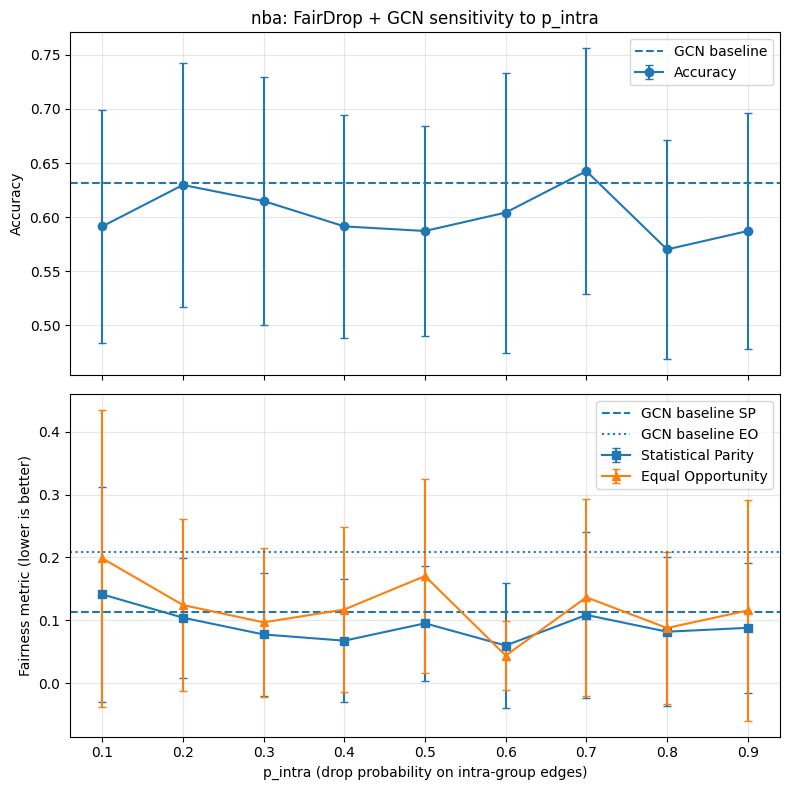

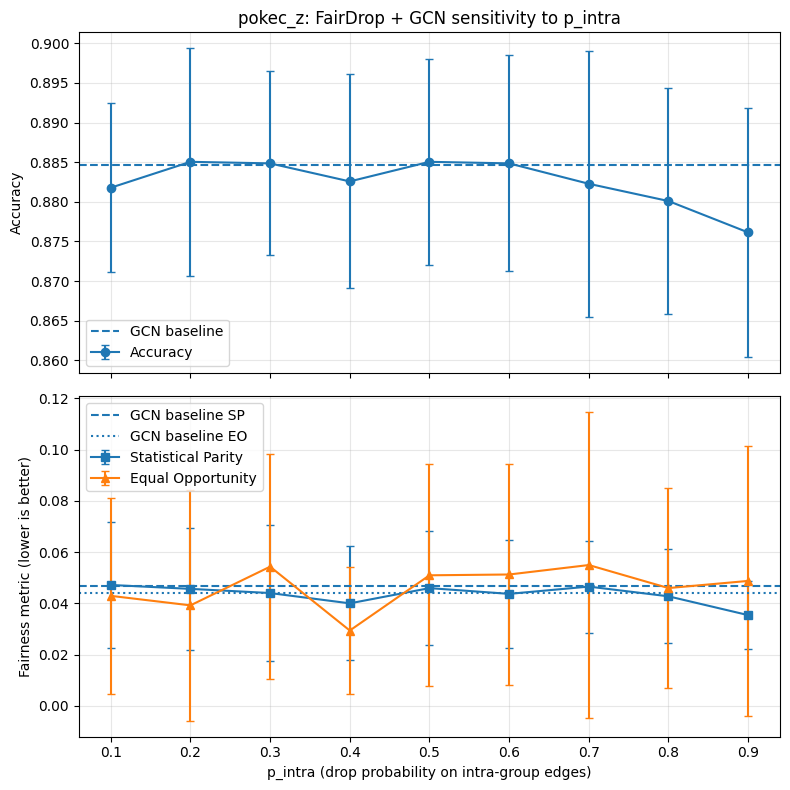

In [ ]:
# =========================================================
# Extra Cell: FairDrop + GCN sweep on p_intra = 0.1 ... 0.9
# =========================================================

import matplotlib.pyplot as plt

P_INTRA_LIST = [round(x, 1) for x in np.arange(0.1, 1.0, 0.1)]
print("Sweep p_intra:", P_INTRA_LIST)

SWEEP_SAVE_DIR = os.path.join(SAVE_DIR, "fairdrop_p_intra_sweep")
os.makedirs(SWEEP_SAVE_DIR, exist_ok=True)


def run_fairdrop_sweep(data_dict, p_intra_list):
    """
    扫 FairDrop + GCN 的 p_intra
    这里 p_intra 是 drop probability
    跨组边始终不 drop
    """
    all_dataset_results = {}

    for ds_name, data in data_dict.items():
        base_cfg = RUN_CONFIG[ds_name]
        dataset_rows = []

        print(f"\n{'='*70}")
        print(f"Running FairDrop + GCN sweep on {ds_name}")
        print(f"{'='*70}")

        for p_intra in p_intra_list:
            cfg = dict(base_cfg)
            cfg["fair_keep_same"] = 1.0 - p_intra   # drop prob -> keep prob
            cfg["fair_keep_diff"] = 1.0             # cross-group edges: no drop

            print(f"\n--- p_intra(drop) = {p_intra:.1f} | keep_same = {cfg['fair_keep_same']:.1f} ---")

            for seed in SEEDS:
                result = train_and_evaluate(
                    data=data,
                    cfg=cfg,
                    seed=seed,
                    use_fairdrop=True,
                    pretrained_encoder_state=None
                )

                row = {
                    "dataset": ds_name,
                    "p_intra": p_intra,
                    "seed": seed,
                    "accuracy": result["accuracy"],
                    "statistical_parity": result["statistical_parity"],
                    "equal_opportunity": result["equal_opportunity"],
                }
                dataset_rows.append(row)

                print(
                    f"seed={seed} | "
                    f"acc={row['accuracy']:.4f} | "
                    f"sp={row['statistical_parity']:.4f} | "
                    f"eo={row['equal_opportunity']:.4f}"
                )

        df = pd.DataFrame(dataset_rows)
        all_dataset_results[ds_name] = df

        # save raw per-seed results
        df.to_csv(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_per_seed.csv"),
            index=False
        )

    return all_dataset_results


def summarize_fairdrop_sweep(all_dataset_results):

    summary_dict = {}

    for ds_name, df in all_dataset_results.items():
        summary = (
            df.groupby("p_intra")[["accuracy", "statistical_parity", "equal_opportunity"]]
            .agg(["mean", "std"])
            .reset_index()
        )

        # flatten columns
        summary.columns = [
            "p_intra",
            "acc_mean", "acc_std",
            "sp_mean", "sp_std",
            "eo_mean", "eo_std"
        ]

        summary_dict[ds_name] = summary
        summary.to_csv(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_summary.csv"),
            index=False
        )

        print(f"\n===== Summary: {ds_name} =====")
        display(summary)

    return summary_dict


def plot_fairdrop_sweep(summary_dict, baseline_summary_df=None):

    for ds_name, summary in summary_dict.items():
        fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        x = summary["p_intra"].values

        # -------------------------
        # top: accuracy
        # -------------------------
        axes[0].errorbar(
            x, summary["acc_mean"], yerr=summary["acc_std"],
            marker="o", capsize=3, label="Accuracy"
        )
        axes[0].set_ylabel("Accuracy")
        axes[0].set_title(f"{ds_name}: FairDrop + GCN sensitivity to p_intra")
        axes[0].grid(True, alpha=0.3)

        # baseline horizontal line if available
        if baseline_summary_df is not None:
            row = baseline_summary_df[baseline_summary_df["dataset"] == ds_name]
            if len(row) > 0:
                acc_base = row["acc_mean"].values[0]
                axes[0].axhline(acc_base, linestyle="--", label="GCN baseline")
                axes[0].legend()

        # -------------------------
        # bottom: fairness metrics
        # -------------------------
        axes[1].errorbar(
            x, summary["sp_mean"], yerr=summary["sp_std"],
            marker="s", capsize=3, label="Statistical Parity"
        )
        axes[1].errorbar(
            x, summary["eo_mean"], yerr=summary["eo_std"],
            marker="^", capsize=3, label="Equal Opportunity"
        )

        # baseline fairness horizontal lines if available
        if baseline_summary_df is not None:
            row = baseline_summary_df[baseline_summary_df["dataset"] == ds_name]
            if len(row) > 0:
                sp_base = row["sp_mean"].values[0]
                eo_base = row["eo_mean"].values[0]
                axes[1].axhline(sp_base, linestyle="--", label="GCN baseline SP")
                axes[1].axhline(eo_base, linestyle=":", label="GCN baseline EO")

        axes[1].set_xlabel("p_intra (drop probability on intra-group edges)")
        axes[1].set_ylabel("Fairness metric (lower is better)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        fig.savefig(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_curve.png"),
            dpi=300,
            bbox_inches="tight"
        )


# -------------------------
# run sweep
# -------------------------
fairdrop_sweep_results = run_fairdrop_sweep(DATA_OBJECTS, P_INTRA_LIST)

# per-dataset summary
fairdrop_sweep_summary = summarize_fairdrop_sweep(fairdrop_sweep_results)

# plot curves
plot_fairdrop_sweep(
    summary_dict=fairdrop_sweep_summary,
    baseline_summary_df=baseline_summary if "baseline_summary" in globals() else None
)

Sweep p_edge: [0.1, 0.2, 0.3, 0.4]
Sweep p_feat: [0.1, 0.2, 0.3, 0.4]

Running Contrastive + GCN augmentation sweep on nba

--- p_edge=0.1, p_feat=0.1 ---
seed=0 | acc=0.5106 | sp=0.1645 | eo=0.1250
seed=1 | acc=0.7234 | sp=0.0960 | eo=0.0526
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=4 | acc=0.7234 | sp=0.1310 | eo=0.0737
seed=5 | acc=0.6383 | sp=0.0146 | eo=0.1500
seed=6 | acc=0.6809 | sp=0.3514 | eo=0.5789
seed=7 | acc=0.6596 | sp=0.3095 | eo=0.3866
seed=8 | acc=0.7660 | sp=0.0455 | eo=0.1111
seed=9 | acc=0.4894 | sp=0.1703 | eo=0.1092

--- p_edge=0.1, p_feat=0.2 ---
seed=0 | acc=0.5532 | sp=0.0433 | eo=0.0625
seed=1 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=2 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=3 | acc=0.7234 | sp=0.0965 | eo=0.3333
seed=4 | acc=0.6596 | sp=0.0381 | eo=0.2632
seed=5 | acc=0.6809 | sp=0.0351 | eo=0.2500
seed=6 | acc=0.7234 | sp=0.2784 | eo=0.4316
seed=7 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=8 | acc=0.8298 |

,p_edge,p_feat,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.1,0.619149,0.108698,0.128269,0.124469,0.158717,0.183575
1,0.1,0.2,0.625532,0.116191,0.083905,0.107922,0.167017,0.154260
2,0.1,0.3,0.617021,0.105194,0.117630,0.105918,0.092258,0.102812
3,0.1,0.4,0.636170,0.098502,0.146615,0.115578,0.158959,0.136976
4,0.2,0.1,0.614894,0.089401,0.112180,0.104631,0.157851,0.184776
5,0.2,0.2,0.648936,0.102408,0.153490,0.100921,0.219312,0.185376
6,0.2,0.3,0.589362,0.061051,0.126133,0.111363,0.170629,0.198717
7,0.2,0.4,0.602128,0.073053,0.136404,0.132020,0.194378,0.180723
8,0.3,0.1,0.614894,0.118866,0.119857,0.134075,0.176358,0.193930
9,0.3,0.2,0.595745,0.075057,0.121385,0.104398,0.164756,0.111219



===== Summary: pokec_z =====


,p_edge,p_feat,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.1,0.885644,0.012621,0.045617,0.024784,0.048663,0.025028
1,0.1,0.2,0.881881,0.011678,0.040964,0.023660,0.040343,0.026864
2,0.1,0.3,0.883366,0.010528,0.039633,0.024148,0.032202,0.021737
3,0.1,0.4,0.883465,0.010437,0.046646,0.023267,0.046940,0.032446
4,0.2,0.1,0.884257,0.011264,0.043787,0.018955,0.033924,0.028565
5,0.2,0.2,0.884455,0.011817,0.043034,0.020217,0.046643,0.031889
6,0.2,0.3,0.882277,0.011069,0.047716,0.022388,0.040377,0.038353
7,0.2,0.4,0.883564,0.012047,0.046186,0.020950,0.039772,0.031430
8,0.3,0.1,0.885248,0.011607,0.047612,0.019352,0.043703,0.037084
9,0.3,0.2,0.883960,0.010476,0.045208,0.021922,0.039945,0.022085


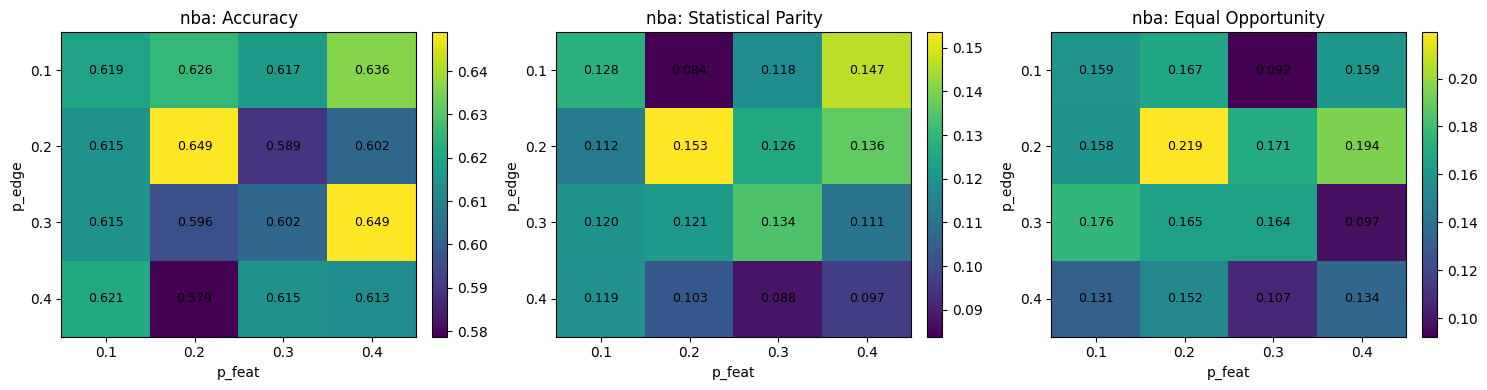

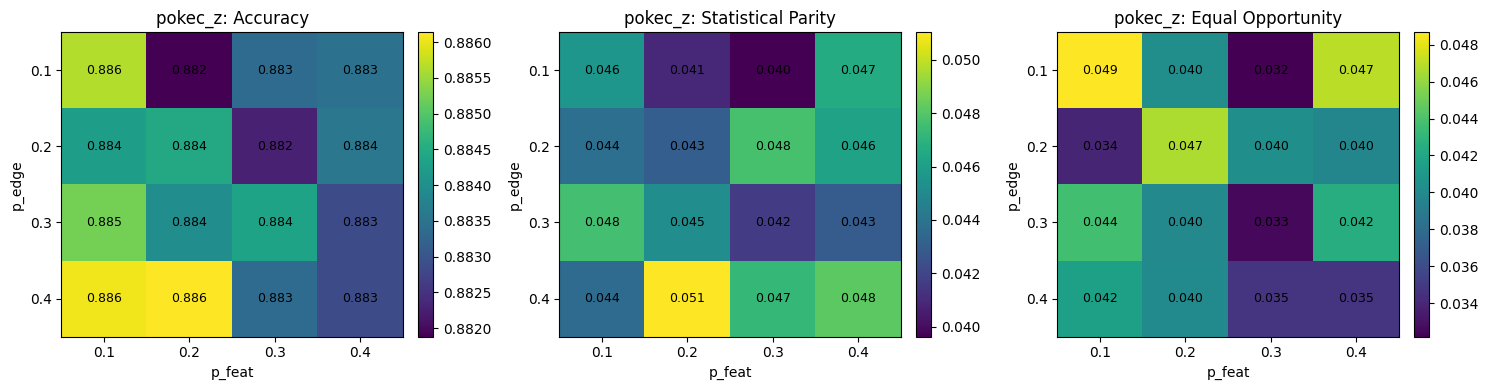


===== Ranked configs: nba =====


,p_edge,p_feat,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std,tradeoff_score
0,0.3,0.4,0.648936,0.117504,0.110679,0.107115,0.097309,0.099160,0.440948
1,0.4,0.3,0.614894,0.079894,0.087785,0.088172,0.106942,0.099391,0.420166
2,0.1,0.3,0.617021,0.105194,0.117630,0.105918,0.092258,0.102812,0.407134
3,0.4,0.4,0.612766,0.109780,0.096828,0.110154,0.133995,0.144570,0.381944
4,0.1,0.2,0.625532,0.116191,0.083905,0.107922,0.167017,0.154260,0.374610
5,0.4,0.1,0.621277,0.108860,0.119116,0.139080,0.131151,0.201364,0.371010
6,0.2,0.1,0.614894,0.089401,0.112180,0.104631,0.157851,0.184776,0.344862
7,0.1,0.1,0.619149,0.108698,0.128269,0.124469,0.158717,0.183575,0.332162
8,0.1,0.4,0.636170,0.098502,0.146615,0.115578,0.158959,0.136976,0.330596
9,0.4,0.2,0.578723,0.058312,0.103037,0.100339,0.151884,0.113546,0.323803



===== Ranked configs: pokec_z =====


,p_edge,p_feat,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std,tradeoff_score
0,0.1,0.3,0.883366,0.010528,0.039633,0.024148,0.032202,0.021737,0.811530
1,0.3,0.3,0.884356,0.011383,0.041617,0.020434,0.032544,0.022854,0.810196
2,0.2,0.1,0.884257,0.011264,0.043787,0.018955,0.033924,0.028565,0.806546
3,0.4,0.3,0.883366,0.010287,0.047230,0.019603,0.034700,0.038737,0.801437
4,0.4,0.1,0.886040,0.012519,0.043608,0.024760,0.041537,0.023620,0.800895
5,0.1,0.2,0.881881,0.011678,0.040964,0.023660,0.040343,0.026864,0.800574
6,0.4,0.4,0.882871,0.011909,0.048168,0.020995,0.034684,0.033023,0.800020
7,0.3,0.2,0.883960,0.010476,0.045208,0.021922,0.039945,0.022085,0.798807
8,0.2,0.4,0.883564,0.012047,0.046186,0.020950,0.039772,0.031430,0.797607
9,0.3,0.4,0.882871,0.012207,0.042959,0.020795,0.042436,0.026923,0.797476


In [ ]:
# =========================================================
# Extra Cell A: Contrastive + GCN sweep on p_edge and p_feat
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P_EDGE_LIST = [0.1, 0.2, 0.3, 0.4]
P_FEAT_LIST = [0.1, 0.2, 0.3, 0.4]

print("Sweep p_edge:", P_EDGE_LIST)
print("Sweep p_feat:", P_FEAT_LIST)

CONTRASTIVE_SWEEP_DIR = os.path.join(SAVE_DIR, "contrastive_pedge_pfeat_sweep")
os.makedirs(CONTRASTIVE_SWEEP_DIR, exist_ok=True)


def run_contrastive_aug_sweep(data_dict, p_edge_list, p_feat_list):
    """
    Sweep contrastive hyperparameters:
      - p_edge
      - p_feat
    Model:
      Contrastive Pre-train + GCN
    """
    all_dataset_results = {}

    for ds_name, data in data_dict.items():
        base_cfg = RUN_CONFIG[ds_name]
        rows = []

        print(f"\n{'='*75}")
        print(f"Running Contrastive + GCN augmentation sweep on {ds_name}")
        print(f"{'='*75}")

        for p_edge in p_edge_list:
            for p_feat in p_feat_list:
                cfg = dict(base_cfg)
                cfg["edge_drop_prob"] = p_edge
                cfg["feat_mask_prob"] = p_feat

                print(f"\n--- p_edge={p_edge:.1f}, p_feat={p_feat:.1f} ---")

                for seed in SEEDS:
                    pretrained = pretrain_encoder(
                        data=data,
                        cfg=cfg,
                        seed=seed,
                        use_fairdrop=False
                    )

                    result = train_and_evaluate(
                        data=data,
                        cfg=cfg,
                        seed=seed,
                        use_fairdrop=False,
                        pretrained_encoder_state=pretrained
                    )

                    row = {
                        "dataset": ds_name,
                        "p_edge": p_edge,
                        "p_feat": p_feat,
                        "seed": seed,
                        "accuracy": result["accuracy"],
                        "statistical_parity": result["statistical_parity"],
                        "equal_opportunity": result["equal_opportunity"],
                    }
                    rows.append(row)

                    print(
                        f"seed={seed} | "
                        f"acc={row['accuracy']:.4f} | "
                        f"sp={row['statistical_parity']:.4f} | "
                        f"eo={row['equal_opportunity']:.4f}"
                    )

        df = pd.DataFrame(rows)
        all_dataset_results[ds_name] = df

        df.to_csv(
            os.path.join(CONTRASTIVE_SWEEP_DIR, f"{ds_name}_contrastive_aug_per_seed.csv"),
            index=False
        )

    return all_dataset_results


def summarize_contrastive_aug_sweep(all_dataset_results):
    summary_dict = {}

    for ds_name, df in all_dataset_results.items():
        summary = (
            df.groupby(["p_edge", "p_feat"])[["accuracy", "statistical_parity", "equal_opportunity"]]
            .agg(["mean", "std"])
            .reset_index()
        )

        summary.columns = [
            "p_edge", "p_feat",
            "acc_mean", "acc_std",
            "sp_mean", "sp_std",
            "eo_mean", "eo_std"
        ]

        summary_dict[ds_name] = summary

        summary.to_csv(
            os.path.join(CONTRASTIVE_SWEEP_DIR, f"{ds_name}_contrastive_aug_summary.csv"),
            index=False
        )

        print(f"\n===== Summary: {ds_name} =====")
        display(summary.sort_values(["p_edge", "p_feat"]))

    return summary_dict


def plot_contrastive_aug_heatmaps(summary_dict):
    """
    For each dataset, plot 3 heatmaps:
      - accuracy (higher is better)
      - SP (lower is better)
      - EO (lower is better)
    """
    for ds_name, summary in summary_dict.items():
        acc_mat = summary.pivot(index="p_edge", columns="p_feat", values="acc_mean").sort_index().sort_index(axis=1)
        sp_mat  = summary.pivot(index="p_edge", columns="p_feat", values="sp_mean").sort_index().sort_index(axis=1)
        eo_mat  = summary.pivot(index="p_edge", columns="p_feat", values="eo_mean").sort_index().sort_index(axis=1)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        mats = [
            ("Accuracy", acc_mat),
            ("Statistical Parity", sp_mat),
            ("Equal Opportunity", eo_mat),
        ]

        for ax, (title, mat) in zip(axes, mats):
            im = ax.imshow(mat.values, aspect="auto")
            ax.set_title(f"{ds_name}: {title}")
            ax.set_xlabel("p_feat")
            ax.set_ylabel("p_edge")
            ax.set_xticks(range(len(mat.columns)))
            ax.set_xticklabels([f"{x:.1f}" for x in mat.columns])
            ax.set_yticks(range(len(mat.index)))
            ax.set_yticklabels([f"{x:.1f}" for x in mat.index])

            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    ax.text(j, i, f"{mat.values[i, j]:.3f}", ha="center", va="center", fontsize=9)

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

        fig.savefig(
            os.path.join(CONTRASTIVE_SWEEP_DIR, f"{ds_name}_contrastive_aug_heatmaps.png"),
            dpi=300,
            bbox_inches="tight"
        )


def rank_contrastive_aug_configs(summary_dict, alpha=1.0, beta=1.0):
    """
    Optional trade-off score to help decide the parameters, not standard:
      score = acc_mean - alpha * sp_mean - beta * eo_mean
    """
    ranked = {}

    for ds_name, summary in summary_dict.items():
        df = summary.copy()
        df["tradeoff_score"] = df["acc_mean"] - alpha * df["sp_mean"] - beta * df["eo_mean"]
        df = df.sort_values("tradeoff_score", ascending=False).reset_index(drop=True)
        ranked[ds_name] = df

        print(f"\n===== Ranked configs: {ds_name} =====")
        display(df.head(10))

        df.to_csv(
            os.path.join(CONTRASTIVE_SWEEP_DIR, f"{ds_name}_contrastive_aug_ranked.csv"),
            index=False
        )

    return ranked


# -------------------------
# run sweep
# -------------------------
contrastive_aug_sweep_results = run_contrastive_aug_sweep(
    data_dict=DATA_OBJECTS,
    p_edge_list=P_EDGE_LIST,
    p_feat_list=P_FEAT_LIST
)

contrastive_aug_sweep_summary = summarize_contrastive_aug_sweep(contrastive_aug_sweep_results)
plot_contrastive_aug_heatmaps(contrastive_aug_sweep_summary)

# Ranking table
contrastive_aug_ranked = rank_contrastive_aug_configs(
    contrastive_aug_sweep_summary,
    alpha=1.0,
    beta=1.0
)